# Runoff Forecasting — Exploratory Data Analysis

**Team TPR, Final Project — Task 1.**

This notebook explores the NWM and USGS data for both gauges before we train
any deep learning models. The goals are:

1. Understand the target we're trying to predict (USGS streamflow).
2. Understand the baseline we're trying to correct (NWM forecasts).
3. Figure out which features are worth feeding the model.

Sections 1–4: streamflow characterization *(Grady)*
Sections 5–8: NWM error analysis *(Michael)*
Section 9: joint feature correlation
Section 10: written summary

Before running this: make sure you've run
`python scripts/preprocess.py --raw-dir <path-to-raw>` so the parquets exist
in `../data/processed/`.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.3f}".format)

# Load both gauges. Paths are relative to the notebooks/ folder.
df1 = pd.read_parquet("../data/processed/gauge_20380357.parquet")
df2 = pd.read_parquet("../data/processed/gauge_21609641.parquet")

print(f"gauge 20380357 (USGS 09520500): {df1.shape[0]:,} rows, {df1.shape[1]} columns")
print(f"gauge 21609641 (USGS 11266500): {df2.shape[0]:,} rows, {df2.shape[1]} columns")
print(f"time range (both): {df1.index.min()}  →  {df1.index.max()}")
df1.head()

gauge 20380357 (USGS 09520500): 17,533 rows, 38 columns
gauge 21609641 (USGS 11266500): 17,311 rows, 38 columns
time range (both): 2021-04-21 18:00:00+00:00  →  2023-04-22 06:00:00+00:00


,usgs_flow,usgs_estimated,nwm_lead_1,nwm_lead_2,nwm_lead_3,nwm_lead_4,nwm_lead_5,nwm_lead_6,nwm_lead_7,nwm_lead_8,...,resid_lead_9,resid_lead_10,resid_lead_11,resid_lead_12,resid_lead_13,resid_lead_14,resid_lead_15,resid_lead_16,resid_lead_17,resid_lead_18
timestamp,,,,,,,,,,,,,,,,,,,,,
2021-04-21 18:00:00+00:00,0.200,False,0.440,0.830,1.490,2.480,3.760,5.240,6.750,8.070,...,-8.920,-9.710,-10.270,-10.650,-10.900,-11.060,-11.160,-11.230,-11.260,-11.290
2021-04-21 19:00:00+00:00,0.200,False,0.440,0.830,1.490,2.480,3.760,5.240,6.750,8.060,...,-8.920,-9.710,-10.270,-10.640,-10.890,-11.050,-11.150,-11.220,-11.260,-11.280
2021-04-21 20:00:00+00:00,0.195,False,0.440,0.830,1.490,2.480,3.760,5.240,6.740,8.060,...,-8.915,-9.705,-10.265,-10.645,-10.885,-11.045,-11.155,-11.215,-11.255,-11.275
2021-04-21 21:00:00+00:00,0.188,False,0.430,0.830,1.490,2.470,3.760,5.230,6.740,8.050,...,-8.912,-9.702,-10.262,-10.642,-10.892,-11.052,-11.152,-11.212,-11.252,-11.272
2021-04-21 22:00:00+00:00,0.180,False,0.430,0.820,1.490,2.470,3.750,5.230,6.740,8.050,...,-8.920,-9.700,-10.260,-10.640,-10.890,-11.050,-11.150,-11.210,-11.250,-11.270


---
# Part A — Streamflow characterization (Grady)

The goal here is to understand what the USGS observations look like: when do
peaks happen, are the train/val/test periods comparable, and how is flow
distributed?

## 1. Time series with split boundaries

Plot `usgs_flow` across the full two-year window for both gauges, with the
train/val and val/test cutoffs shown as dashed lines.

**Look for:** does the test period look anything like training? If the test
window contains flow regimes the training data never saw, our model will
extrapolate poorly.

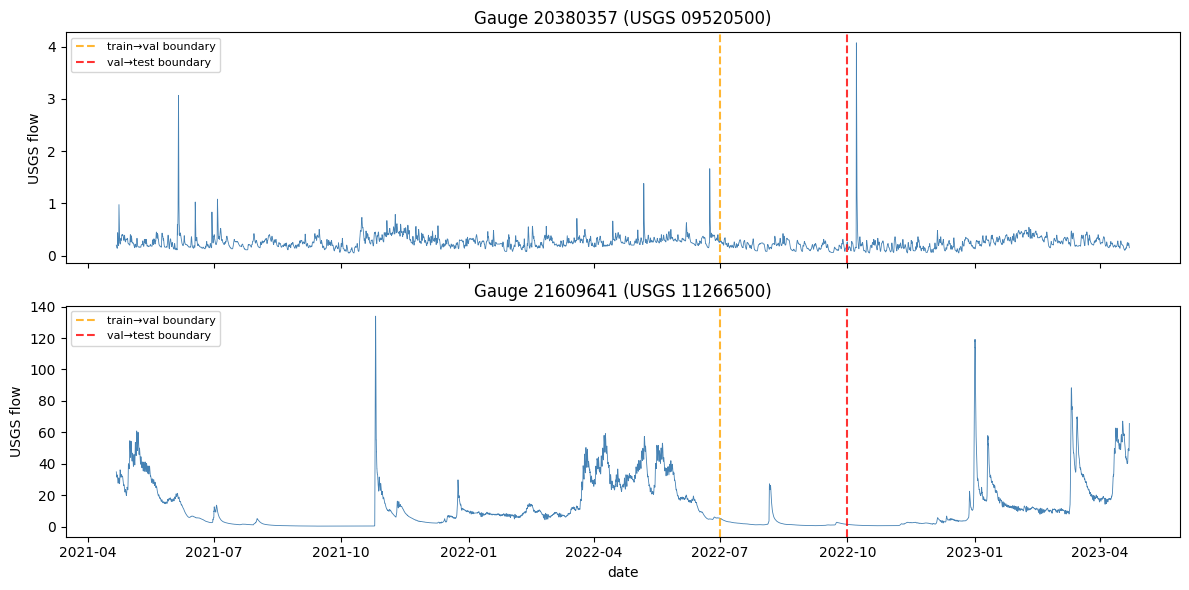

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
train_end = pd.Timestamp("2022-06-30 23:00", tz="UTC")
val_end   = pd.Timestamp("2022-09-30 23:00", tz="UTC")

for ax, df, name in zip(axes, [df1, df2], ["20380357 (USGS 09520500)", "21609641 (USGS 11266500)"]):
    ax.plot(df.index, df["usgs_flow"], lw=0.6, color="steelblue")
    ax.axvline(train_end, color="orange", ls="--", alpha=0.8, label="train→val boundary")
    ax.axvline(val_end,   color="red",    ls="--", alpha=0.8, label="val→test boundary")
    ax.set_ylabel("USGS flow")
    ax.set_title(f"Gauge {name}")
    ax.legend(loc="upper left", fontsize=8)

axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()

**Your notes here:** after you run this, write down what you see. Some
prompts:
- Which months have the biggest peaks? What season is that?
- Is the test window (Oct 2022 – Apr 2023) representative of training?
- Are the two gauges on similar scales, or very different?

## 2. Seasonality — monthly and hourly means

Aggregate flow by month and by hour of day. This shows whether the rivers
have a seasonal cycle (snowmelt? monsoon?) and whether there's any daily
pattern.

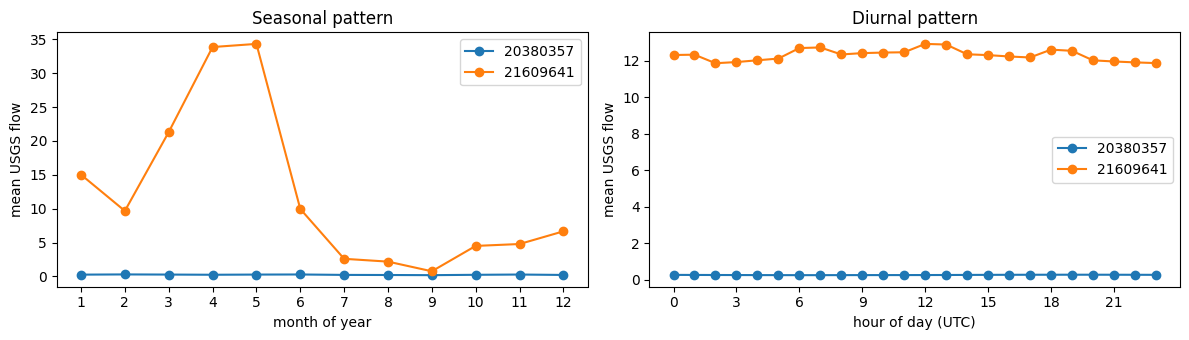

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for df, name, color in [(df1, "20380357", "C0"), (df2, "21609641", "C1")]:
    df["usgs_flow"].groupby(df.index.month).mean().plot(
        ax=axes[0], marker="o", label=name, color=color)
    df["usgs_flow"].groupby(df.index.hour).mean().plot(
        ax=axes[1], marker="o", label=name, color=color)

axes[0].set(xlabel="month of year", ylabel="mean USGS flow",
            title="Seasonal pattern", xticks=range(1, 13))
axes[0].legend()

axes[1].set(xlabel="hour of day (UTC)", ylabel="mean USGS flow",
            title="Diurnal pattern", xticks=range(0, 24, 3))
axes[1].legend()

plt.tight_layout()
plt.show()

**Your notes here:** does either gauge show a strong seasonal signal? A
daily signal? If there's a daily pattern that's driven by snowmelt or ET,
we may want to include hour-of-day as a feature (we explore this in
section 9).

## 3. Flow distribution (log scale)

Streamflow is almost always right-skewed — lots of low-flow hours, a few big
events. This matters because MSE loss will be dominated by errors at high
flows. Histograms on a log-x axis reveal the shape.

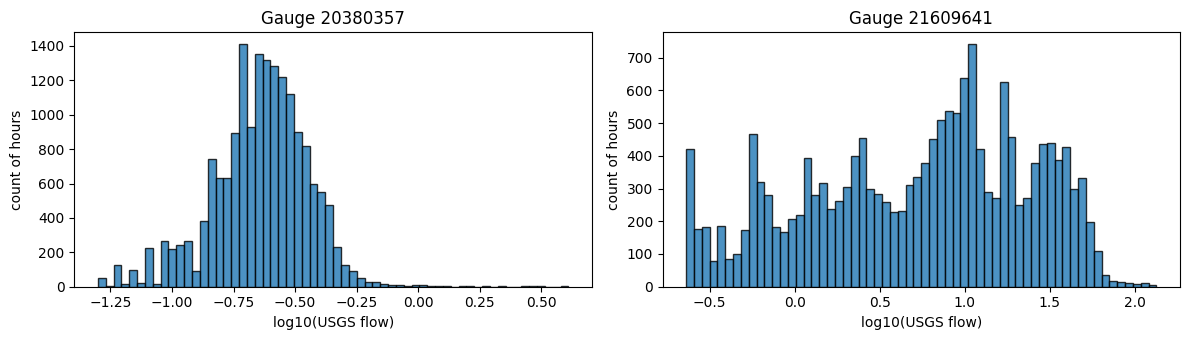

Gauge 20380357: min=0.05  median=0.24  mean=0.25  max=4.07  skew=8.85
Gauge 21609641: min=0.23  median=6.84  mean=12.31  max=133.94  skew=1.94


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, df, name in zip(axes, [df1, df2], ["20380357", "21609641"]):
    ax.hist(np.log10(df["usgs_flow"].clip(lower=1e-3)),
            bins=60, edgecolor="black", alpha=0.8)
    ax.set(xlabel="log10(USGS flow)", ylabel="count of hours",
           title=f"Gauge {name}")

plt.tight_layout()
plt.show()

# Numeric summary of skewness/spread
for df, name in [(df1, "20380357"), (df2, "21609641")]:
    s = df["usgs_flow"]
    print(f"Gauge {name}: "
          f"min={s.min():.2f}  median={s.median():.2f}  "
          f"mean={s.mean():.2f}  max={s.max():.2f}  "
          f"skew={s.skew():.2f}")

**Your notes here:** is the distribution heavy-tailed? High skew values
(>1) confirm right-skew. Implication for modeling: we may want to consider
log-transforming flow as a preprocessing step, or using an asymmetric loss
function. Worth mentioning in the report's method section.

## 4. Top-10 highest-flow events

Identify the ten biggest storm hours per gauge. Are they clustered (one big
storm event) or spread out over the two years?

In [5]:
for df, name in [(df1, "20380357"), (df2, "21609641")]:
    top = df.nlargest(10, "usgs_flow")[["usgs_flow", "nwm_lead_1"]]
    print(f"\nTop-10 highest-flow hours — gauge {name}")
    print(top.to_string())


Top-10 highest-flow hours — gauge 20380357
                           usgs_flow  nwm_lead_1
timestamp                                       
2022-10-07 10:00:00+00:00      4.072       9.910
2022-10-07 09:00:00+00:00      3.907       7.910
2022-10-07 11:00:00+00:00      3.907      10.480
2022-10-07 12:00:00+00:00      3.583      10.510
2022-10-07 13:00:00+00:00      3.215      10.270
2022-10-07 08:00:00+00:00      3.115       6.900
2021-06-05 14:00:00+00:00      3.067      14.140
2021-06-05 15:00:00+00:00      3.010       6.050
2022-10-07 14:00:00+00:00      2.877       9.910
2021-06-05 13:00:00+00:00      2.820       8.840

Top-10 highest-flow hours — gauge 21609641
                           usgs_flow  nwm_lead_1
timestamp                                       
2021-10-25 17:00:00+00:00    133.935     121.140
2021-10-25 18:00:00+00:00    133.868     126.120
2021-10-25 16:00:00+00:00    129.760     114.290
2021-10-25 19:00:00+00:00    129.338     129.280
2021-10-25 15:00:00+00:00    1

**Your notes here:** do the top-10 cluster in time? If yes, the model will
need to forecast through *that specific* storm event in the test set (storms
in the 2022-10-07 range for gauge 20380357, or 2021-10-25 for 21609641).
That's where it has to do well.

---
# Part B — NWM error analysis (Michael)

Now we examine the NWM forecasts themselves. The DL model's job is to
correct NWM's errors, so understanding the structure of those errors
directly informs model design.

## 5. NWM vs USGS scatter at multiple leads

For each gauge, scatter NWM forecast against observed USGS flow at four
lead times (1h, 6h, 12h, 18h). A 1:1 red line marks perfect agreement.

**Read the plot:** points on the line = perfect forecast; points above = NWM
underestimates; points below = NWM overestimates. Tight cloud around the
line = low noise; fat cloud = high noise.

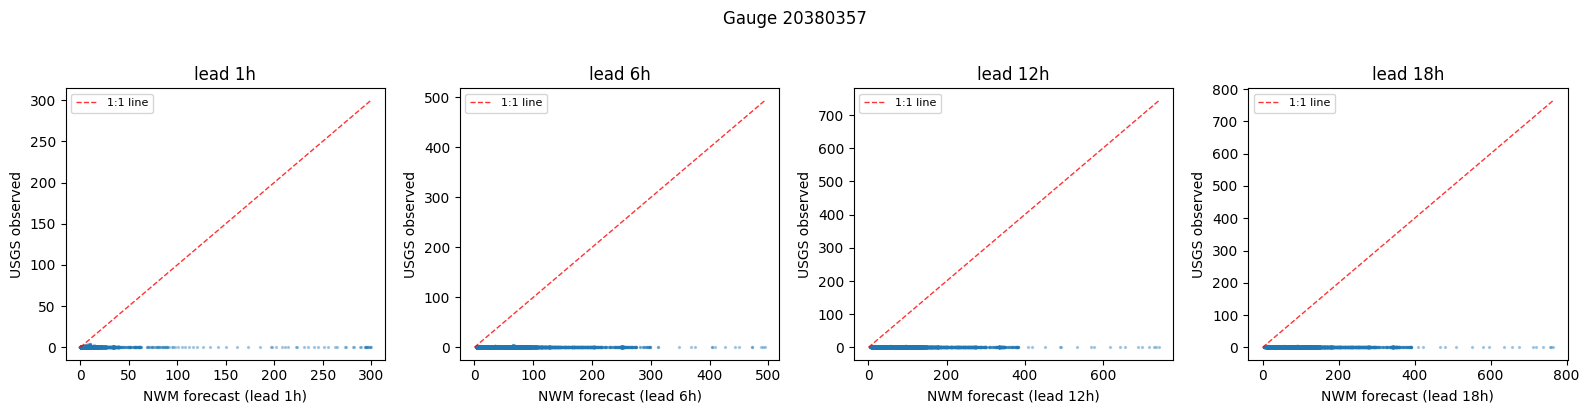

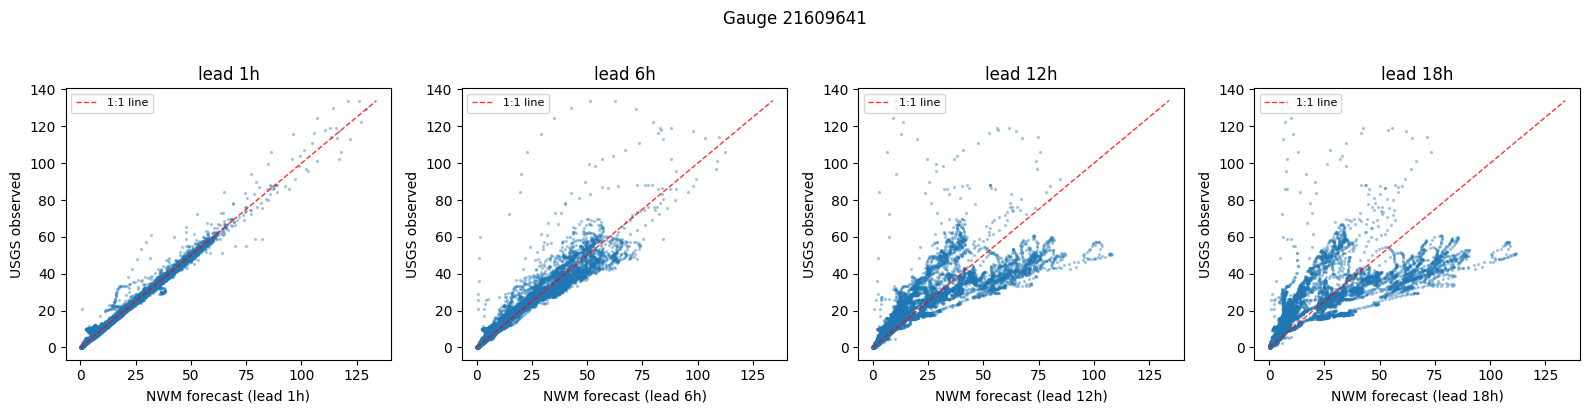

In [6]:
for df, name in [(df1, "20380357"), (df2, "21609641")]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, h in zip(axes, [1, 6, 12, 18]):
        ax.scatter(df[f"nwm_lead_{h}"], df["usgs_flow"], s=2, alpha=0.3)
        m = max(df[f"nwm_lead_{h}"].max(), df["usgs_flow"].max())
        ax.plot([0, m], [0, m], "r--", alpha=0.8, lw=1, label="1:1 line")
        ax.set(xlabel=f"NWM forecast (lead {h}h)",
               ylabel="USGS observed",
               title=f"lead {h}h")
        ax.legend(loc="upper left", fontsize=8)
    fig.suptitle(f"Gauge {name}", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

**Your notes here:** this is the single most important plot for motivating
the project. On gauge 20380357 you should see NWM dramatically above the 1:1
line (massive overprediction). On 21609641 you should see a much tighter
cloud — NWM does reasonably well here and we're looking for smaller
refinements. Does the cloud get fatter at longer leads (18h vs 1h)?

## 6. Error vs lead time

Compute the mean residual (bias) and the RMSE (magnitude) of residuals at
each lead 1..18. Bias tells us whether NWM is systematically over/under;
RMSE tells us how large the errors are overall.

**Expected pattern:** error magnitude grows with lead time — the further
ahead you forecast, the worse you do. If this pattern is *absent*, that's
interesting and worth noting.

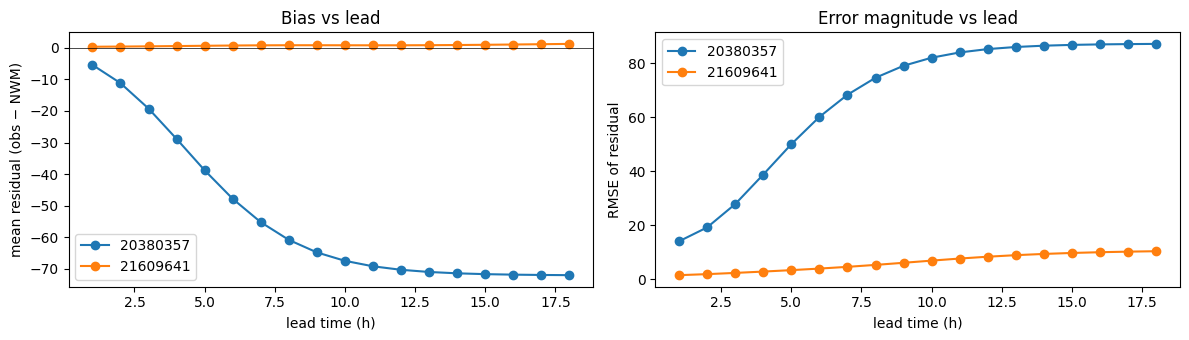

In [7]:
leads = list(range(1, 19))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for df, name, color in [(df1, "20380357", "C0"), (df2, "21609641", "C1")]:
    mean_r = [df[f"resid_lead_{h}"].mean() for h in leads]
    rmse_r = [np.sqrt((df[f"resid_lead_{h}"]**2).mean()) for h in leads]
    axes[0].plot(leads, mean_r, marker="o", label=name, color=color)
    axes[1].plot(leads, rmse_r, marker="o", label=name, color=color)

axes[0].axhline(0, color="k", lw=0.5)
axes[0].set(xlabel="lead time (h)", ylabel="mean residual (obs − NWM)",
            title="Bias vs lead")
axes[0].legend()

axes[1].set(xlabel="lead time (h)", ylabel="RMSE of residual",
            title="Error magnitude vs lead")
axes[1].legend()

plt.tight_layout()
plt.show()

**Your notes here:** 
- Does RMSE grow with lead? By how much (e.g. 2x from lead 1 to lead 18)?
- Is the bias constant across leads or does it grow?
- Different behavior between the two gauges?

## 7. Error vs flow magnitude

Bin observed flow into quartiles (Q1 = lowest 25%, Q4 = highest 25%). For
each bin, compute the mean absolute residual at lead 6. This reveals whether
NWM is bad mostly during high flows, low flows, or uniformly.

If errors are concentrated in the highest quartile, our DL model needs to
focus there — which has loss-function implications we can discuss in the
report.

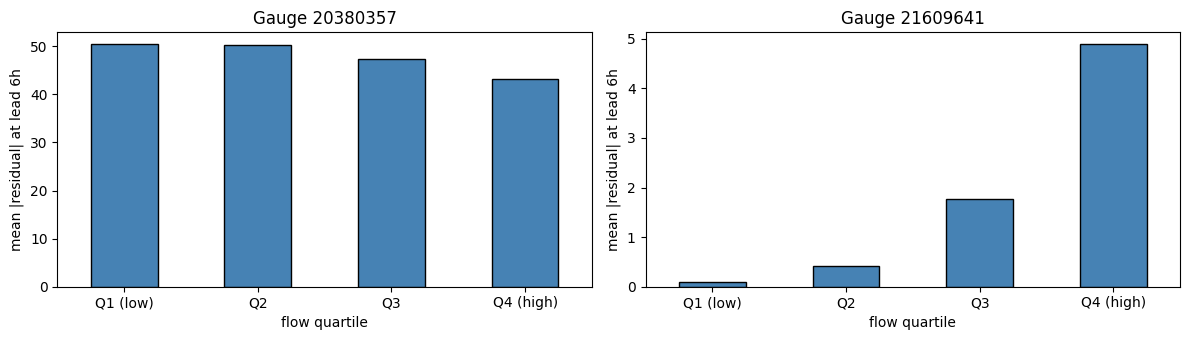

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, df, name in zip(axes, [df1, df2], ["20380357", "21609641"]):
    qs = pd.qcut(df["usgs_flow"], 4,
                 labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"],
                 duplicates="drop")
    by_q = df.groupby(qs, observed=True)["resid_lead_6"].apply(
        lambda s: s.abs().mean())
    by_q.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set(xlabel="flow quartile", ylabel="mean |residual| at lead 6h",
           title=f"Gauge {name}")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Your notes here:** which quartile has the largest absolute error? That's
where NWM needs the most help.

## 8. Autocorrelation of errors

Is NWM's error persistent? If the residual at hour $t$ correlates with the
residual at hour $t-1$, $t-2$, ..., then a sequence model (LSTM/GRU/Transformer)
can exploit that: "NWM has been running 2 cfs high for the last 3 hours, so
it's probably 2 cfs high right now too."

**Expected pattern:** strong autocorrelation at short lags, decaying slowly.
If autocorrelation is zero beyond lag 1, there's nothing for a sequence
model to learn — the residuals are pure white noise.

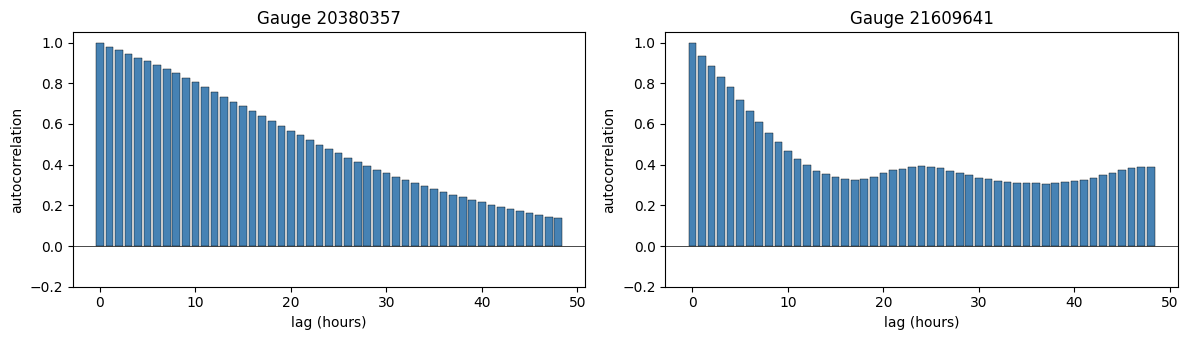

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
max_lag = 48

for ax, df, name in zip(axes, [df1, df2], ["20380357", "21609641"]):
    r = df["resid_lead_1"].dropna()
    acf = [r.autocorr(lag=k) for k in range(max_lag + 1)]
    ax.bar(range(max_lag + 1), acf, width=0.8, color="steelblue",
           edgecolor="black", linewidth=0.3)
    ax.axhline(0, color="k", lw=0.5)
    ax.set(xlabel="lag (hours)", ylabel="autocorrelation",
           title=f"Gauge {name}",
           ylim=(-0.2, 1.05))

plt.tight_layout()
plt.show()

**Your notes here:** how many hours back do the errors remain correlated?
This gives a principled lower bound for the model's lookback window — if
errors are still correlated at lag 24, then a lookback of at least 24 makes
sense. The default `--lookback 48` is reasonable if autocorrelation decays
within 48 hours.

---
# Part C — Feature selection (joint)

## 9. Which features correlate with the residual we want to predict?

Compute the correlation of each candidate feature with `resid_lead_6` (our
target for the 6-hour-ahead residual). Features with near-zero correlation
are unlikely to help the model; features with strong correlation are
high-value inputs.

We include:
- `usgs_flow` (current observation)
- A subset of NWM leads (1, 3, 6, 9, 12, 15, 18)
- `hour` and `doy` (day-of-year) — temporal features

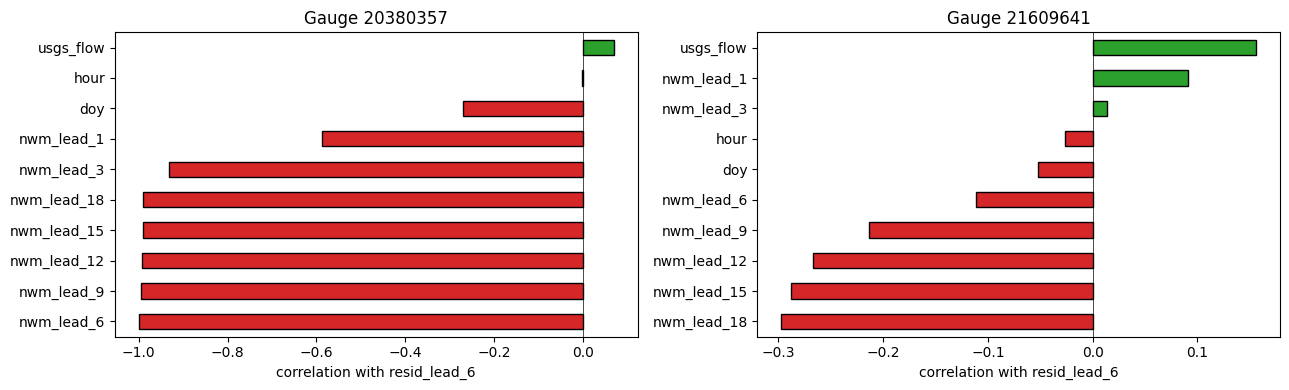


Gauge 20380357 — correlations with resid_lead_6:
nwm_lead_6    -1.000
nwm_lead_9    -0.995
nwm_lead_12   -0.992
nwm_lead_15   -0.991
nwm_lead_18   -0.991
nwm_lead_3    -0.932
nwm_lead_1    -0.586
doy           -0.269
hour          -0.003
usgs_flow      0.069

Gauge 21609641 — correlations with resid_lead_6:
nwm_lead_18   -0.297
nwm_lead_15   -0.288
nwm_lead_12   -0.267
nwm_lead_9    -0.213
nwm_lead_6    -0.112
doy           -0.052
hour          -0.027
nwm_lead_3     0.014
nwm_lead_1     0.091
usgs_flow      0.156


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, name in zip(axes, [df1, df2], ["20380357", "21609641"]):
    tmp = df.copy()
    tmp["hour"] = tmp.index.hour
    tmp["doy"] = tmp.index.dayofyear

    feats = (["usgs_flow"]
             + [f"nwm_lead_{h}" for h in [1, 3, 6, 9, 12, 15, 18]]
             + ["hour", "doy"])

    corrs = tmp[feats].corrwith(tmp["resid_lead_6"]).sort_values()
    colors = ["C3" if v < 0 else "C2" for v in corrs]
    corrs.plot(kind="barh", ax=ax, color=colors, edgecolor="black")
    ax.axvline(0, color="k", lw=0.5)
    ax.set(xlabel="correlation with resid_lead_6",
           title=f"Gauge {name}")

plt.tight_layout()
plt.show()

# Also print the values for the report
for df, name in [(df1, "20380357"), (df2, "21609641")]:
    tmp = df.copy()
    tmp["hour"] = tmp.index.hour
    tmp["doy"] = tmp.index.dayofyear
    feats = (["usgs_flow"]
             + [f"nwm_lead_{h}" for h in [1, 3, 6, 9, 12, 15, 18]]
             + ["hour", "doy"])
    print(f"\nGauge {name} — correlations with resid_lead_6:")
    print(tmp[feats].corrwith(tmp["resid_lead_6"]).sort_values().to_string())

**Your notes here:** which feature has the strongest (absolute) correlation?
Is it consistent across gauges? Any features so weak we should probably
drop them from `default_feature_cols()` in `src/dataset.py`?

---
# 10. Written summary

Fill in after running everything above. ~200 words. Goes into the Data
section of the 5-page report.

**Top three findings:**

1. *(e.g.)* NWM has severe positive bias on gauge 20380357 (~5 cfs mean
   residual, 22× the observed mean flow), suggesting a basin mis-pairing or
   fundamental calibration issue. This means our DL correction has a huge
   amount of signal to learn from. On gauge 21609641, NWM is well-calibrated
   and the correction task is about refining already-reasonable forecasts.

2. *(fill in based on section 6)* Error magnitude grows from ___ at lead 1h
   to ___ at lead 18h, so the model's correction becomes more valuable at
   longer leads.

3. *(fill in based on section 8)* NWM-USGS residuals remain autocorrelated
   for ___ hours, justifying a sequence-model approach with a lookback
   window of at least ___ hours.

**Implications for model design:**

- *(something about which features to include, based on section 9)*
- *(something about loss function or target transformation, based on section 3)*
- *(something about lookback window, based on section 8)*

**Train/test comparability concerns:**

- *(anything from section 1–2 — is the test period representative?)*